In [2]:
from pathlib import Path

DATA_RAW = Path("../data/raw")
DATA_RAW.mkdir(parents=True, exist_ok=True)

arquivos = list(DATA_RAW.glob("*"))
print(f"Arquivos encontrados: {len(arquivos)}\n")
for f in arquivos:
    print(f"{f.name} - {f.stat().st_size / 1024:.1f} KB")

Arquivos encontrados: 3

seqs_test.txt - 29.9 KB
Neg_train_fasta.txt - 78.0 KB
Pos_train_fasta.txt - 56.3 KB


In [3]:
from Bio import SeqIO

# Identifica todos os arquivos FASTA
fasta_files = list(DATA_RAW.glob("*.txt"))

# Carrega cada um em um dicionário
dados = {}
for arquivo in fasta_files:
    records = list(SeqIO.parse(arquivo, "fasta"))
    dados[arquivo.stem] = records  # usa nome do arquivo como chave
    print(f"{arquivo.name}: {len(records)} sequências")

print(f"\nArquivos carregados: {list(dados.keys())}")

seqs_test.txt: 970 sequências
Neg_train_fasta.txt: 1940 sequências
Pos_train_fasta.txt: 1940 sequências

Arquivos carregados: ['seqs_test', 'Neg_train_fasta', 'Pos_train_fasta']


In [4]:
# Mostra as 2 primeiras sequências de cada arquivo
for nome_arquivo, records in dados.items():
    print(f"\n{'='*60}")
    print(f"Arquivo: {nome_arquivo}")
    print(f"{'='*60}")
    
    for i, rec in enumerate(records[:2]):
        print(f"\n[{i}] ID: {rec.id}")
        print(f"    Descrição: {rec.description}")
        print(f"    Tamanho: {len(rec.seq)} bp")
        print(f"    Primeiros 10 caracteres: {str(rec.seq)[:10]}...")


Arquivo: seqs_test

[0] ID: NP00317
    Descrição: NP00317
    Tamanho: 10 bp
    Primeiros 10 caracteres: AGWSSLKGAW...

[1] ID: NP00717
    Descrição: NP00717
    Tamanho: 17 bp
    Primeiros 10 caracteres: DALSPPAAGL...

Arquivo: Neg_train_fasta

[0] ID: non-NeuroP002366
    Descrição: non-NeuroP002366
    Tamanho: 17 bp
    Primeiros 10 caracteres: FLPLLAASFA...

[1] ID: non-NeuroP014978
    Descrição: non-NeuroP014978
    Tamanho: 6 bp
    Primeiros 10 caracteres: QVHHQK...

Arquivo: Pos_train_fasta

[0] ID: NP04987
    Descrição: NP04987
    Tamanho: 8 bp
    Primeiros 10 caracteres: SVQFKPRL...

[1] ID: NP05606
    Descrição: NP05606
    Tamanho: 10 bp
    Primeiros 10 caracteres: APLMGFQGVR...


In [5]:
import pandas as pd

# Cria DataFrame com estatísticas para cada arquivo
for nome_arquivo, records in dados.items():
    stats = []
    for rec in records:
        stats.append({
            "id": rec.id,
            "length": len(rec.seq),
            "gc_content": sum(rec.seq.count(x) for x in "GCgc") / len(rec.seq) * 100 if len(rec.seq) > 0 else 0,
            "n_count": rec.seq.count("N") + rec.seq.count("n"),
        })
    
    df = pd.DataFrame(stats)
    print(f"\n{'='*60}")
    print(f"Arquivo: {nome_arquivo}")
    print(f"{'='*60}")
    print(df.describe())


Arquivo: seqs_test
           length  gc_content     n_count
count  970.000000  970.000000  970.000000
mean    21.106186   11.212066    0.887629
std     18.579483   10.235362    1.218515
min      5.000000    0.000000    0.000000
25%     10.000000    1.517991    0.000000
50%     15.000000   10.000000    0.000000
75%     24.000000   16.666667    1.000000
max    100.000000   56.250000    8.000000

Arquivo: Neg_train_fasta
            length   gc_content      n_count
count  1940.000000  1940.000000  1940.000000
mean     22.144845    12.056406     0.920619
std      17.926679    10.896214     1.232986
min       5.000000     0.000000     0.000000
25%      12.000000     4.624736     0.000000
50%      16.000000    10.000000     1.000000
75%      25.000000    16.666667     1.000000
max     100.000000    57.142857     9.000000

Arquivo: Pos_train_fasta
            length   gc_content      n_count
count  1940.000000  1940.000000  1940.000000
mean     19.700515    11.047022     0.841237
std      1

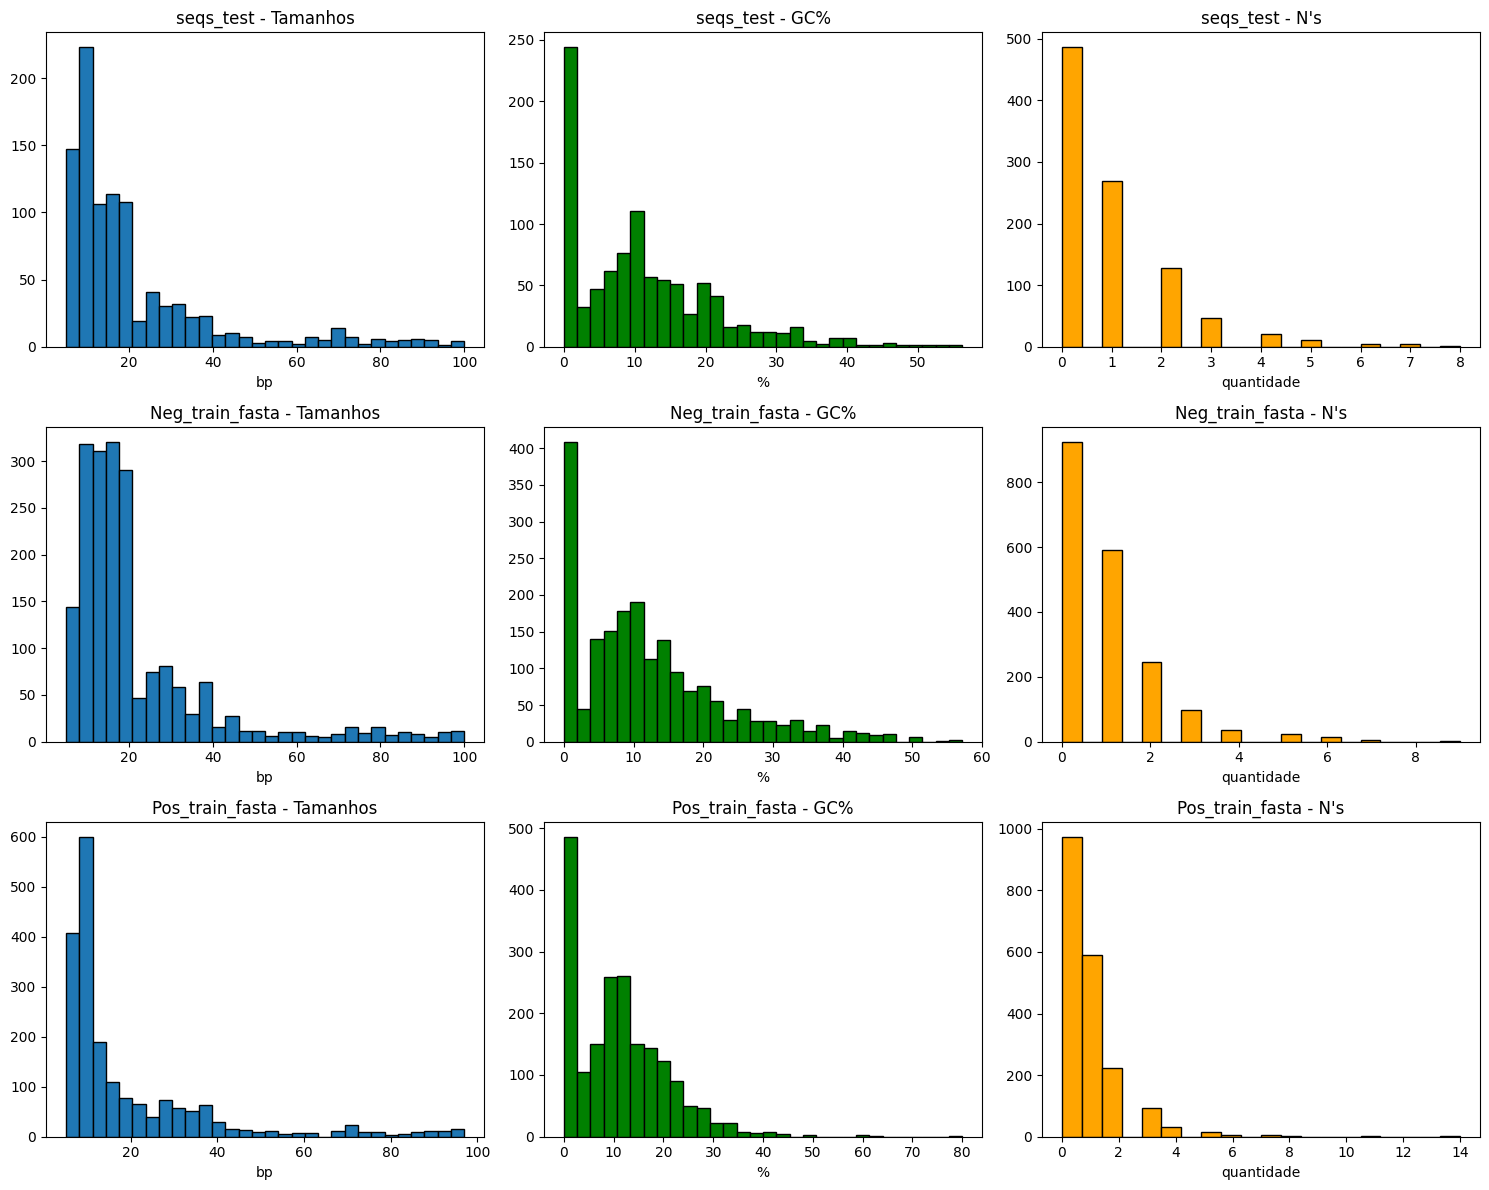

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for idx, (nome, records) in enumerate(dados.items()):
    stats = pd.DataFrame([
        {"length": len(r.seq), 
         "gc": sum(r.seq.count(x) for x in "GCgc") / len(r.seq) * 100,
         "n": r.seq.count("N") + r.seq.count("n")}
        for r in records
    ])
    
    # Tamanhos
    axes[idx, 0].hist(stats["length"], bins=30, edgecolor="black")
    axes[idx, 0].set_title(f"{nome} - Tamanhos")
    axes[idx, 0].set_xlabel("bp")
    
    # GC content
    axes[idx, 1].hist(stats["gc"], bins=30, color="green", edgecolor="black")
    axes[idx, 1].set_title(f"{nome} - GC%")
    axes[idx, 1].set_xlabel("%")
    
    # N count
    axes[idx, 2].hist(stats["n"], bins=20, color="orange", edgecolor="black")
    axes[idx, 2].set_title(f"{nome} - N's")
    axes[idx, 2].set_xlabel("quantidade")

plt.tight_layout()
plt.show()

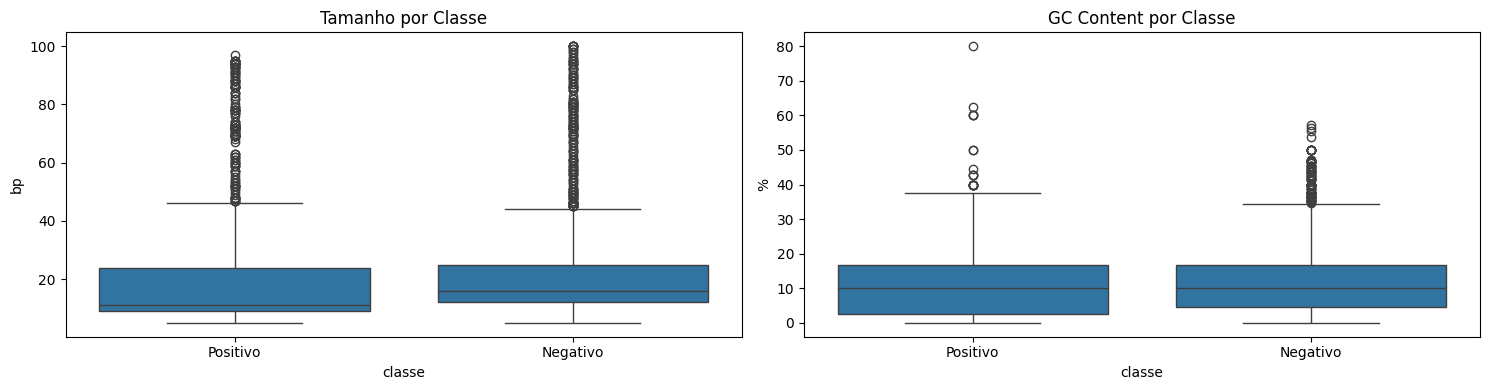

In [8]:
# Compara as classes de treino lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Prepara dados
pos_stats = pd.DataFrame([
    {"length": len(r.seq), "gc": sum(r.seq.count(x) for x in "GCgc") / len(r.seq) * 100}
    for r in dados["Pos_train_fasta"]
])
pos_stats["classe"] = "Positivo"

neg_stats = pd.DataFrame([
    {"length": len(r.seq), "gc": sum(r.seq.count(x) for x in "GCgc") / len(r.seq) * 100}
    for r in dados["Neg_train_fasta"]
])
neg_stats["classe"] = "Negativo"

combined = pd.concat([pos_stats, neg_stats])

# Boxplot tamanhos
sns.boxplot(data=combined, x="classe", y="length", ax=axes[0])
axes[0].set_title("Tamanho por Classe")
axes[0].set_ylabel("bp")

# Boxplot GC content
sns.boxplot(data=combined, x="classe", y="gc", ax=axes[1])
axes[1].set_title("GC Content por Classe")
axes[1].set_ylabel("%")

plt.tight_layout()
plt.show()

## Preprocessamento com MathFeature

Vamos usar os scripts de preprocessamento do MathFeature para:
1. Remover ruído (caracteres inválidos como N, K, etc)
2. Verificar redundância (sequências duplicadas)
3. Contar bases detalhadamente

## DESCOBERTA IMPORTANTE: São Sequências de PROTEÍNAS!

As sequências NÃO são DNA, são **sequências de aminoácidos (proteínas)**!

Isso explica por que os métodos de DNA falharam:
- K-mers DNA: procurava apenas A,T,C,G
- Fourier/Z-curve DNA: não faz sentido para proteínas
- Fickett Score: específico para coding DNA

Precisamos usar métodos específicos para proteínas do MathFeature:
- ExtractionTechniques-Protein.py (AAC, DPC, TPC, k-mer proteína)
- Mappings-Protein.py (4 mapeamentos + Fourier para proteínas)
- Entropy também funciona para proteínas
- ComplexNetworks pode funcionar (grafos de k-mers de aminoácidos)

In [9]:
import subprocess
import sys

MATHFEATURE_DIR = Path("/home/jonathan/code/desafio_CD_Bioinfo/MathFeature")
sys.path.insert(0, str(MATHFEATURE_DIR))

DATA_PROC = Path("../data/processed")
DATA_PROC.mkdir(parents=True, exist_ok=True)

print("MathFeature preprocessing tools carregados")
print(f"Diretório: {MATHFEATURE_DIR}")
print(f"Saída preprocessada: {DATA_PROC}")

MathFeature preprocessing tools carregados
Diretório: /home/jonathan/code/desafio_CD_Bioinfo/MathFeature
Saída preprocessada: ../data/processed


### 1. Verificar Redundância nos Dados de Treino

Vamos verificar se existem sequências duplicadas dentro de cada classe

In [10]:
# Verifica redundância manualmente primeiro
def check_duplicates(records, nome):
    sequences = [str(rec.seq) for rec in records]
    unique_seqs = set(sequences)
    
    duplicates = len(sequences) - len(unique_seqs)
    
    print(f"\n{nome}:")
    print(f"  Total de sequências: {len(sequences)}")
    print(f"  Sequências únicas: {len(unique_seqs)}")
    print(f"  Duplicadas: {duplicates}")
    
    if duplicates > 0:
        # Encontra quais estão duplicadas
        from collections import Counter
        seq_counts = Counter(sequences)
        dup_seqs = {seq: count for seq, count in seq_counts.items() if count > 1}
        print(f"  Número de sequências com duplicatas: {len(dup_seqs)}")
        print(f"  Exemplo (primeira duplicada): {list(dup_seqs.items())[0][1]} cópias")
    
    return duplicates

print("="*60)
print("VERIFICAÇÃO DE REDUNDÂNCIA")
print("="*60)

# Verifica cada arquivo
dup_pos = check_duplicates(dados["Pos_train_fasta"], "Positivos (treino)")
dup_neg = check_duplicates(dados["Neg_train_fasta"], "Negativos (treino)")
dup_test = check_duplicates(dados["seqs_test"], "Test")

print(f"\n{'='*60}")
if dup_pos + dup_neg + dup_test > 0:
    print("ATENÇÃO: Redundância detectada!")
else:
    print("OK: Nenhuma redundância detectada")

VERIFICAÇÃO DE REDUNDÂNCIA

Positivos (treino):
  Total de sequências: 1940
  Sequências únicas: 1940
  Duplicadas: 0

Negativos (treino):
  Total de sequências: 1940
  Sequências únicas: 1940
  Duplicadas: 0

Test:
  Total de sequências: 970
  Sequências únicas: 970
  Duplicadas: 0

OK: Nenhuma redundância detectada


### 2. Verificar Sobreposição entre Treino e Teste

Importante: sequências do teste não devem aparecer no treino

In [11]:
# Verifica se há sequências do teste no treino
train_seqs = set(str(rec.seq) for rec in dados["Pos_train_fasta"] + dados["Neg_train_fasta"])
test_seqs = set(str(rec.seq) for rec in dados["seqs_test"])

overlap = train_seqs.intersection(test_seqs)

print("="*60)
print("VERIFICAÇÃO DE SOBREPOSIÇÃO TREINO-TESTE")
print("="*60)
print(f"\nSequências de treino: {len(train_seqs)}")
print(f"Sequências de teste: {len(test_seqs)}")
print(f"Sobreposição: {len(overlap)}")

if len(overlap) > 0:
    print(f"\nATENÇÃO: {len(overlap)} sequências aparecem em AMBOS treino e teste!")
    print("Isso é um problema grave de data leakage!")
    print(f"\nExemplo de sequência duplicada: {list(overlap)[0][:50]}...")
else:
    print("\nOK: Nenhuma sobreposição detectada entre treino e teste")

VERIFICAÇÃO DE SOBREPOSIÇÃO TREINO-TESTE

Sequências de treino: 3880
Sequências de teste: 970
Sobreposição: 0

OK: Nenhuma sobreposição detectada entre treino e teste


### 3. Verificar Tipo de Sequência e Caracteres Inválidos

Vamos identificar se são sequências de DNA ou Proteína (aminoácidos)

In [ ]:
# Verifica tipo de sequência e caracteres inválidos
def check_sequence_type(records, nome):
    """Identifica se são sequências DNA ou Proteína"""
    
    # Caracteres válidos
    dna_chars = set("ATCGatcgNn")
    protein_chars = set("ACDEFGHIKLMNPQRSTVWYacdefghiklmnpqrstvwy*X")  # 20 aminoácidos + stop + unknown
    
    # Amostra 100 sequências para análise
    sample = records[:min(100, len(records))]
    
    dna_count = 0
    protein_count = 0
    invalid_chars_found = set()
    
    for rec in sample:
        seq_chars = set(str(rec.seq))
        
        # Verifica se é DNA
        if seq_chars.issubset(dna_chars):
            dna_count += 1
        # Verifica se é Proteína
        elif seq_chars.issubset(protein_chars):
            protein_count += 1
        else:
            # Tem caracteres inválidos
            invalid = seq_chars - protein_chars - dna_chars
            invalid_chars_found.update(invalid)
    
    # Determina tipo predominante
    if dna_count > protein_count:
        seq_type = "DNA"
        valid_chars = dna_chars
    else:
        seq_type = "PROTEÍNA (Aminoácidos)"
        valid_chars = protein_chars
    
    # Verifica TODAS as sequências agora que sabemos o tipo
    invalid_seqs = []
    for rec in records:
        seq_chars = set(str(rec.seq))
        invalid = seq_chars - valid_chars
        if invalid:
            invalid_seqs.append(rec.id)
            invalid_chars_found.update(invalid)
    
    print(f"\n{nome}:")
    print(f"  Tipo de sequência: {seq_type}")
    print(f"  Total de sequências: {len(records)}")
    print(f"  Sequências com caracteres inválidos: {len(invalid_seqs)}")
    
    if invalid_chars_found:
        print(f"  Caracteres inválidos encontrados: {sorted(invalid_chars_found)}")
        if invalid_seqs:
            print(f"  Exemplos de IDs afetados: {invalid_seqs[:5]}")
    else:
        print(f"  OK: Apenas caracteres válidos")
    
    return seq_type, len(invalid_seqs)

print("="*60)
print("IDENTIFICAÇÃO DO TIPO DE SEQUÊNCIA")
print("="*60)

type_pos, inv_pos = check_sequence_type(dados["Pos_train_fasta"], "Positivos (treino)")
type_neg, inv_neg = check_sequence_type(dados["Neg_train_fasta"], "Negativos (treino)")
type_test, inv_test = check_sequence_type(dados["seqs_test"], "Test")

print(f"\n{'='*60}")
print(f"CONCLUSÃO: As sequências são do tipo {type_pos}")
print(f"{'='*60}")

if inv_pos + inv_neg + inv_test > 0:
    print("\nATENÇÃO: Caracteres inválidos detectados!")
    print("Recomenda-se usar o preprocessing do MathFeature")
else:
    print("\nOK: Todas as sequências contêm apenas caracteres válidos")

VERIFICAÇÃO DE CARACTERES INVÁLIDOS

Positivos (treino):
  Sequências com caracteres inválidos: 1940
  Caracteres inválidos encontrados: ['D', 'E', 'F', 'H', 'I', 'K', 'L', 'M', 'P', 'Q', 'R', 'S', 'V', 'W', 'Y']
  Exemplos de IDs afetados: ['NP04987', 'NP05606', 'NP03263', 'NP03547', 'NP00699']

Negativos (treino):
  Sequências com caracteres inválidos: 1939
  Caracteres inválidos encontrados: ['D', 'E', 'F', 'H', 'I', 'K', 'L', 'M', 'P', 'Q', 'R', 'S', 'V', 'W', 'Y']
  Exemplos de IDs afetados: ['non-NeuroP002366', 'non-NeuroP014978', 'non-NeuroP033408', 'non-NeuroP007366', 'non-NeuroP006873']

Test:
  Sequências com caracteres inválidos: 970
  Caracteres inválidos encontrados: ['D', 'E', 'F', 'H', 'I', 'K', 'L', 'M', 'P', 'Q', 'R', 'S', 'V', 'W', 'Y']
  Exemplos de IDs afetados: ['NP00317', 'NP00717', 'NP01482', 'NP03336', 'NP02850']

ATENÇÃO: Caracteres inválidos detectados!
Recomenda-se usar o preprocessing do MathFeature


### 4. Aplicar Preprocessing do MathFeature (se necessário)

Se detectamos problemas acima, vamos limpar os dados

In [13]:
# Aplica preprocessing do MathFeature nos 3 arquivos
preprocessing_script = MATHFEATURE_DIR / "preprocessing" / "preprocessing.py"

arquivos_para_processar = [
    (DATA_RAW / "Pos_train_fasta.txt", DATA_PROC / "Pos_train_clean.fasta"),
    (DATA_RAW / "Neg_train_fasta.txt", DATA_PROC / "Neg_train_clean.fasta"),
    (DATA_RAW / "seqs_test.txt", DATA_PROC / "seqs_test_clean.fasta")
]

print("="*60)
print("APLICANDO PREPROCESSING DO MATHFEATURE")
print("="*60)
print("\nRemove caracteres inválidos (N, K, etc) e limpa sequências\n")

for input_file, output_file in arquivos_para_processar:
    print(f"Processando: {input_file.name}")
    
    cmd = [
        "python", str(preprocessing_script),
        "-i", str(input_file),
        "-o", str(output_file)
    ]
    
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    if result.returncode == 0:
        # Conta sequências antes e depois
        original_count = len(list(SeqIO.parse(input_file, "fasta")))
        clean_count = len(list(SeqIO.parse(output_file, "fasta")))
        
        print(f"  Original: {original_count} seqs")
        print(f"  Limpo: {clean_count} seqs")
        
        if original_count != clean_count:
            print(f"  ATENÇÃO: {original_count - clean_count} sequências foram removidas!")
    else:
        print(f"  ERRO: {result.stderr}")
    
    print()

print("="*60)
print("PREPROCESSING CONCLUÍDO")
print("="*60)
print(f"\nArquivos limpos salvos em: {DATA_PROC}/")
print("\nUsar esses arquivos limpos no notebook de feature engineering!")

APLICANDO PREPROCESSING DO MATHFEATURE

Remove caracteres inválidos (N, K, etc) e limpa sequências

Processando: Pos_train_fasta.txt
  Original: 1940 seqs
  Limpo: 0 seqs
  ATENÇÃO: 1940 sequências foram removidas!

Processando: Neg_train_fasta.txt
  Original: 1940 seqs
  Limpo: 0 seqs
  ATENÇÃO: 1940 sequências foram removidas!

Processando: Neg_train_fasta.txt
  Original: 1940 seqs
  Limpo: 1 seqs
  ATENÇÃO: 1939 sequências foram removidas!

Processando: seqs_test.txt
  Original: 1940 seqs
  Limpo: 1 seqs
  ATENÇÃO: 1939 sequências foram removidas!

Processando: seqs_test.txt
  Original: 970 seqs
  Limpo: 0 seqs
  ATENÇÃO: 970 sequências foram removidas!

PREPROCESSING CONCLUÍDO

Arquivos limpos salvos em: ../data/processed/

Usar esses arquivos limpos no notebook de feature engineering!
  Original: 970 seqs
  Limpo: 0 seqs
  ATENÇÃO: 970 sequências foram removidas!

PREPROCESSING CONCLUÍDO

Arquivos limpos salvos em: ../data/processed/

Usar esses arquivos limpos no notebook de feat

### 5. Análise Comparativa: Antes vs Depois do Preprocessing

In [ ]:
# Compara estatísticas antes e depois
def compare_stats(original_file, clean_file, nome):
    original = list(SeqIO.parse(original_file, "fasta"))
    clean = list(SeqIO.parse(clean_file, "fasta"))
    
    # Stats originais
    orig_lengths = [len(r.seq) for r in original]
    orig_gc = [sum(r.seq.count(x) for x in "GCgc") / len(r.seq) * 100 for r in original]
    orig_n = [r.seq.count("N") + r.seq.count("n") for r in original]
    
    # Stats limpos
    clean_lengths = [len(r.seq) for r in clean]
    clean_gc = [sum(r.seq.count(x) for x in "GCgc") / len(r.seq) * 100 for r in clean]
    clean_n = [r.seq.count("N") + r.seq.count("n") for r in clean]
    
    print(f"\n{'='*60}")
    print(f"{nome}")
    print(f"{'='*60}")
    print(f"Sequências: {len(original)} → {len(clean)}")
    print(f"Tamanho médio: {np.mean(orig_lengths):.1f} → {np.mean(clean_lengths):.1f} bp")
    print(f"GC médio: {np.mean(orig_gc):.2f}% → {np.mean(clean_gc):.2f}%")
    print(f"N's médio: {np.mean(orig_n):.2f} → {np.mean(clean_n):.2f}")
    print(f"N's total: {sum(orig_n)} → {sum(clean_n)}")

import numpy as np

print("="*60)
print("COMPARAÇÃO: ORIGINAL vs LIMPO")
print("="*60)

if all(Path(f[1]).exists() for f in arquivos_para_processar):
    compare_stats(
        DATA_RAW / "Pos_train_fasta.txt",
        DATA_PROC / "Pos_train_clean.fasta",
        "Positivos (treino)"
    )
    
    compare_stats(
        DATA_RAW / "Neg_train_fasta.txt",
        DATA_PROC / "Neg_train_clean.fasta",
        "Negativos (treino)"
    )
    
    compare_stats(
        DATA_RAW / "seqs_test.txt",
        DATA_PROC / "seqs_test_clean.fasta",
        "Test"
    )
else:
    print("\nArquivos limpos ainda não foram gerados.")
    print("Execute a célula anterior primeiro!")